# Neural Network — Electron Energy Regression

Mirrors the XGBoost regression pipeline (`XGB_Regression/XGB_Reg.py`):

* same 20 features (read from `Input_lists/XGB_REG_INPUT.txt`)
* same RelMAD grading metric — `mean(|E_pred − E_true| / E_true)`
* same log-target trick — train on `log(E)` with MSE; un-log at inference

Differs in the model class (`ThreeLayerRegressor` — same architecture as the
classifier sibling but no sigmoid on the output) and in the Optuna search
space (NN-specific: layer widths, learning rate, weight decay, dropout, batch).

The final tuned model is saved together with the scaler, feature list, and
hyperparameters into a single `.pth` artifact, so the inference cell at the
bottom can be pointed at the grader's blind test set with one path change.


In [1]:
import copy
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import optuna
import pandas as pd
import torch
from torch import nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

sys.path.append('..')  # I_Project root
from Modules.Utils import XGB_REG_DATALOADER  # filters to true electrons
from Modules.models import ThreeLayerRegressor

SEED = 42
np.random.seed(SEED)
torch.manual_seed(SEED)

device = torch.device(
    'mps' if torch.backends.mps.is_available()
    else 'cuda' if torch.cuda.is_available()
    else 'cpu'
)
print(f"Using device: {device}")


Using device: mps


## Data — load, restrict to XGB regression features, train/val/test split, scale

In [2]:
DATA_PATH = '/Users/prometheus/Documents/Python/I_Project/Data/AppML_InitialProject_train.h5'
FEATURE_LIST_PATH = '/Users/prometheus/Documents/Python/I_Project/Input_lists/XGB_REG_INPUT.txt'
TARGET_COL = 'p_Truth_Energy'

with open(FEATURE_LIST_PATH) as f:
    features = [line.strip() for line in f if line.strip()]

# XGB_REG_DATALOADER filters to true electrons (p_Truth_isElectron == 1) and
# does an 80/20 split. We carve a further val set out of the train portion so
# we have train/val/test = 64/16/20 of the electron-only data.
X_trainval, X_test, y_trainval, y_test = XGB_REG_DATALOADER(
    DATA_PATH, TARGET_COL, test_size=0.2,
)
X_trainval = X_trainval[features]
X_test = X_test[features]

X_train, X_val, y_train, y_val = train_test_split(
    X_trainval, y_trainval, test_size=0.2, random_state=SEED,
)

scaler = StandardScaler()
X_train_s = scaler.fit_transform(X_train).astype(np.float32)
X_val_s = scaler.transform(X_val).astype(np.float32)
X_test_s = scaler.transform(X_test).astype(np.float32)

# Log-target trick: MSE on log(E) ≈ relative error on E for small deviations,
# so the optimisation signal aligns with the RelMAD grader.
log_y_train = np.log(y_train.values).astype(np.float32)
log_y_val = np.log(y_val.values).astype(np.float32)
log_y_test = np.log(y_test.values).astype(np.float32)

print(f"Features: {len(features)}")
print(f"Train: {X_train_s.shape}   Val: {X_val_s.shape}   Test: {X_test_s.shape}")
print(f"Target range: [{y_trainval.min():.2f}, {y_trainval.max():.2f}] GeV")


Dataset loaded from /Users/prometheus/Documents/Python/I_Project/Data/AppML_InitialProject_train.h5 with shape (37800, 140)
No missing values detected in the dataset.
Dropped 47 highly correlated features
Features: 20
Train: (24192, 20)   Val: (6048, 20)   Test: (7560, 20)
Target range: [520.52, 871351.50] GeV


## Training & evaluation helpers

In [3]:
def make_loader(X, y_log, batch_size, shuffle):
    ds = TensorDataset(
        torch.tensor(X, dtype=torch.float32),
        torch.tensor(y_log, dtype=torch.float32),
    )
    return DataLoader(ds, batch_size=batch_size, shuffle=shuffle)


def relmad(y_true, y_pred):
    """Project's grading metric: mean(|E_pred − E_true| / E_true)."""
    y_true = np.asarray(y_true, dtype=float)
    y_pred = np.asarray(y_pred, dtype=float)
    return float(np.mean(np.abs(y_pred - y_true) / y_true))


def predict_geV(model, X_scaled):
    """Forward pass on already-scaled features and undo the log transform."""
    model.eval()
    with torch.no_grad():
        log_pred = model(torch.tensor(X_scaled, dtype=torch.float32).to(device))
    return np.exp(log_pred.cpu().numpy())


def train_one(model, train_loader, val_loader, lr, weight_decay,
              max_epochs=200, patience=15):
    """Train one configuration to convergence.

    Returns (best_state_dict, train_losses, val_losses, best_epoch). The model
    object is mutated; callers should `load_state_dict(best_state)` afterwards
    if they want the best-val-loss snapshot rather than the final-epoch weights.
    """
    optimizer = optim.AdamW(model.parameters(), lr=lr, weight_decay=weight_decay)
    scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, patience=5, factor=0.5)
    criterion = nn.MSELoss()

    best_val = float('inf')
    best_state = None
    best_epoch = 0
    counter = 0
    train_losses, val_losses = [], []

    for epoch in range(1, max_epochs + 1):
        model.train()
        tl = 0.0
        for xb, yb in train_loader:
            xb, yb = xb.to(device), yb.to(device)
            optimizer.zero_grad()
            loss = criterion(model(xb), yb)
            loss.backward()
            optimizer.step()
            tl += loss.item()
        tl /= len(train_loader)

        model.eval()
        vl = 0.0
        with torch.no_grad():
            for xb, yb in val_loader:
                xb, yb = xb.to(device), yb.to(device)
                vl += criterion(model(xb), yb).item()
        vl /= len(val_loader)
        scheduler.step(vl)

        train_losses.append(tl)
        val_losses.append(vl)

        if vl < best_val:
            best_val = vl
            best_state = copy.deepcopy(model.state_dict())
            best_epoch = epoch
            counter = 0
        else:
            counter += 1
            if counter >= patience:
                break

    return best_state, train_losses, val_losses, best_epoch


## Optuna hyperparameter tuning

Sweeps over architecture (layer widths, dropout) and optimisation
(learning rate, weight decay, batch size). Each trial trains a fresh model
on train with early-stopping on val; the trial value is **RelMAD on val** —
the same metric the grader uses, so the search is aligned with the goal.

In [ ]:
"""
N_TRIALS = 400  #


def objective(trial):
    params = {
        'first_layer':  trial.suggest_categorical('first_layer',  [64, 128, 256, 512]),
        'second_layer': trial.suggest_categorical('second_layer', [32, 64, 128, 256]),
        'third_layer':  trial.suggest_categorical('third_layer',  [16, 32, 64, 128]),
        'dropout':      trial.suggest_float('dropout', 0.0, 0.4),
        'lr':           trial.suggest_float('lr', 1e-4, 1e-2, log=True),
        'weight_decay': trial.suggest_float('weight_decay', 1e-6, 1e-2, log=True),
        'batch_size':   trial.suggest_categorical('batch_size', [64, 128, 256, 512]),
    }

    train_loader = make_loader(X_train_s, log_y_train, params['batch_size'], shuffle=True)
    val_loader = make_loader(X_val_s, log_y_val, params['batch_size'], shuffle=False)

    model = ThreeLayerRegressor(
        input_size=len(features),
        first_layer_size=params['first_layer'],
        second_layer_size=params['second_layer'],
        third_layer_size=params['third_layer'],
        dropout=params['dropout'],
    ).to(device)

    best_state, *_ = train_one(
        model, train_loader, val_loader,
        lr=params['lr'], weight_decay=params['weight_decay'],
    )
    model.load_state_dict(best_state)
    y_pred_val = predict_geV(model, X_val_s)
    return relmad(y_val.values, y_pred_val)


optuna.logging.set_verbosity(optuna.logging.WARNING)
study = optuna.create_study(
    direction='minimize',
    sampler=optuna.samplers.TPESampler(seed=SEED),
)
study.optimize(objective, n_trials=N_TRIALS, show_progress_bar=True)

best_params = study.best_params
print(f"\nBest trial #{study.best_trial.number}: RelMAD = {study.best_value:.5f}")
print("Best params:")
for k, v in best_params.items():
    print(f"  {k:<14} {v}")

"""

#best params from 400 trials:
best_params = {
    'first_layer':  64,
    'second_layer': 64,
    'third_layer':  64,
    'dropout':      0.0372860735260292,
    'lr':           0.007451457163428394,
    'weight_decay': 0.0066717547182973845,
    'batch_size':   256,
}


  0%|          | 0/400 [00:00<?, ?it/s]


Best trial #146: RelMAD = 0.22800
Best params:
  first_layer    64
  second_layer   64
  third_layer    64
  dropout        0.0372860735260292
  lr             0.007451457163428394
  weight_decay   0.0066717547182973845
  batch_size     256


## Train the final tuned model

Same hyperparameters Optuna landed on, but with a more generous epoch / patience
budget so the final fit isn't stopped prematurely by an unlucky plateau.

In [5]:
final_train_loader = make_loader(X_train_s, log_y_train, best_params['batch_size'], shuffle=True)
final_val_loader = make_loader(X_val_s, log_y_val, best_params['batch_size'], shuffle=False)

model = ThreeLayerRegressor(
    input_size=len(features),
    first_layer_size=best_params['first_layer'],
    second_layer_size=best_params['second_layer'],
    third_layer_size=best_params['third_layer'],
    dropout=best_params['dropout'],
).to(device)

best_state, train_losses, val_losses, best_epoch = train_one(
    model, final_train_loader, final_val_loader,
    lr=best_params['lr'], weight_decay=best_params['weight_decay'],
    max_epochs=300, patience=25,
)
model.load_state_dict(best_state)

y_pred_val = predict_geV(model, X_val_s)
y_pred_test = predict_geV(model, X_test_s)

print(f"Best epoch: {best_epoch}")
print(f"\n=== top20_tuned (NN) ===")
print(f"  RelMAD (val):  {relmad(y_val.values, y_pred_val):.5f}")
print(f"  RelMAD (test): {relmad(y_test.values, y_pred_test):.5f}")


Best epoch: 83

=== top20_tuned (NN) ===
  RelMAD (val):  0.23569
  RelMAD (test): 0.23254


## Diagnostic plots — saved to `NN_Reg_plots/`

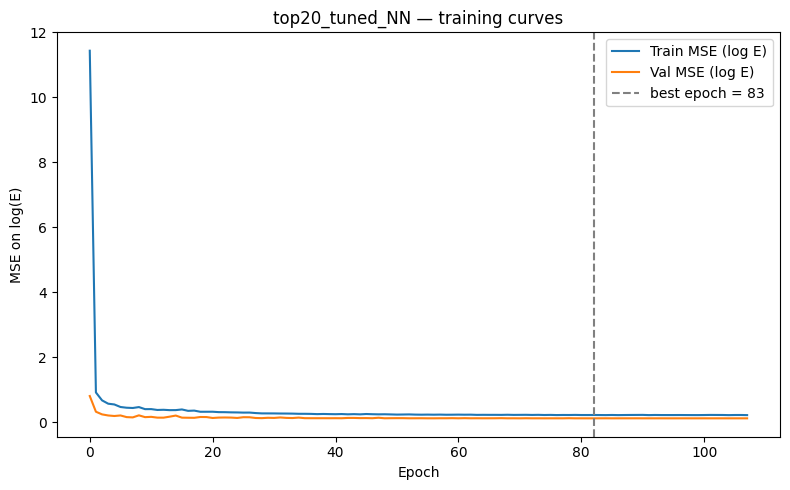

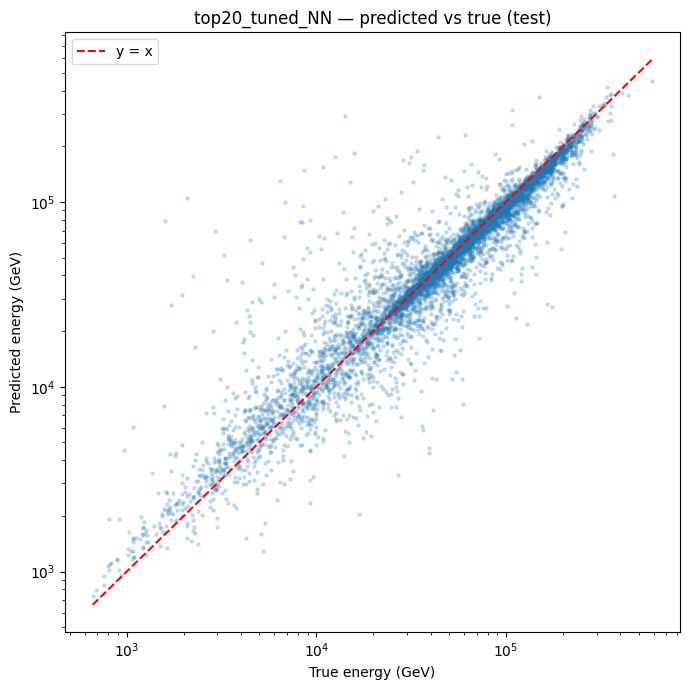

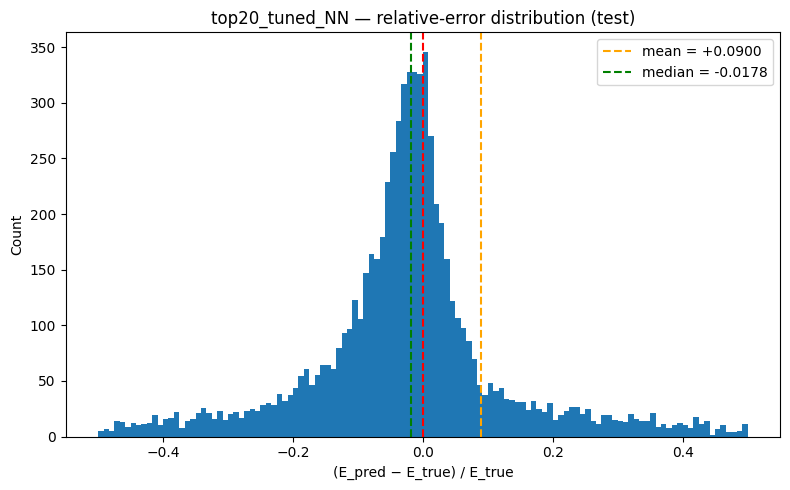

Plots saved to /Users/prometheus/Documents/Python/I_Project/NN_Reg/NN_Reg_plots


In [6]:
PLOT_DIR = Path('NN_Reg_plots')
PLOT_DIR.mkdir(exist_ok=True)
TAG = 'top20_tuned_NN'

# 1) Training curves
fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(train_losses, label='Train MSE (log E)')
ax.plot(val_losses, label='Val MSE (log E)')
ax.axvline(best_epoch - 1, color='gray', ls='--', label=f'best epoch = {best_epoch}')
ax.set_xlabel('Epoch')
ax.set_ylabel('MSE on log(E)')
ax.set_title(f'{TAG} — training curves')
ax.legend()
fig.tight_layout()
fig.savefig(PLOT_DIR / f'{TAG}_training_curves.png', dpi=120)
plt.show()

# 2) Predicted vs true (log-log — energies span a wide dynamic range)
fig, ax = plt.subplots(figsize=(7, 7))
ax.scatter(y_test, y_pred_test, alpha=0.2, s=5)
lo = float(min(np.min(y_test), np.min(y_pred_test)))
hi = float(max(np.max(y_test), np.max(y_pred_test)))
ax.plot([lo, hi], [lo, hi], 'r--', label='y = x')
ax.set_xscale('log'); ax.set_yscale('log')
ax.set_xlabel('True energy (GeV)')
ax.set_ylabel('Predicted energy (GeV)')
ax.set_title(f'{TAG} — predicted vs true (test)')
ax.legend()
fig.tight_layout()
fig.savefig(PLOT_DIR / f'{TAG}_pred_vs_true.png', dpi=120)
plt.show()

# 3) Relative error distribution — direct visualisation of RelMAD
rel = (np.asarray(y_pred_test) - np.asarray(y_test)) / np.asarray(y_test)
fig, ax = plt.subplots(figsize=(8, 5))
ax.hist(rel, bins=120, range=(-0.5, 0.5))
ax.axvline(0, color='red', ls='--')
ax.axvline(rel.mean(), color='orange', ls='--', label=f'mean = {rel.mean():+.4f}')
ax.axvline(np.median(rel), color='green', ls='--', label=f'median = {np.median(rel):+.4f}')
ax.set_xlabel('(E_pred − E_true) / E_true')
ax.set_ylabel('Count')
ax.set_title(f'{TAG} — relative-error distribution (test)')
ax.legend()
fig.tight_layout()
fig.savefig(PLOT_DIR / f'{TAG}_rel_error.png', dpi=120)
plt.show()

print(f"Plots saved to {PLOT_DIR.resolve()}")


## Save artifact for inference

Single `.pth` bundles everything inference needs: weights, scaler, feature
ordering, hyperparameters, and the log-target flag. One file = one load.

In [7]:
ARTIFACT_PATH = 'NN_Reg_artifact.pth'

torch.save({
    'state_dict': model.state_dict(),
    'scaler': scaler,
    'features': features,
    'params': best_params,
    'target_col': TARGET_COL,
    'log_target': True,
}, ARTIFACT_PATH)

print(f"Saved artifact → {Path(ARTIFACT_PATH).resolve()}")


Saved artifact → /Users/prometheus/Documents/Python/I_Project/NN_Reg/NN_Reg_artifact.pth


## Inference on new data

`predict_energies(hdf_path)` is the single entry point you need at submission
time — it loads the artifact, rebuilds the model, applies the saved scaler to
the saved feature subset, and returns predictions in GeV.

Replace `INFERENCE_PATH` with the grader's test HDF when submitting.

In [8]:
def predict_energies(hdf_path, artifact_path=ARTIFACT_PATH):
    """Apply the saved tuned NN to a new HDF file. Returns predictions in GeV."""
    # weights_only=False because the artifact also pickles the StandardScaler.
    art = torch.load(artifact_path, weights_only=False, map_location=device)

    inf_model = ThreeLayerRegressor(
        input_size=len(art['features']),
        first_layer_size=art['params']['first_layer'],
        second_layer_size=art['params']['second_layer'],
        third_layer_size=art['params']['third_layer'],
        dropout=art['params']['dropout'],
    ).to(device)
    inf_model.load_state_dict(art['state_dict'])
    inf_model.eval()

    df = pd.read_hdf(hdf_path)
    X_new_s = art['scaler'].transform(df[art['features']]).astype(np.float32)

    with torch.no_grad():
        log_pred = inf_model(torch.tensor(X_new_s).to(device))
    return np.exp(log_pred.cpu().numpy()) if art['log_target'] else log_pred.cpu().numpy()


# Demo: point this at the grader's blind test file at submission time.
INFERENCE_PATH = DATA_PATH
preds = predict_energies(INFERENCE_PATH)
print(f"Made {len(preds)} predictions.")
print(f"Range:    [{preds.min():.2f}, {preds.max():.2f}] GeV")
print(f"First 5:  {preds[:5]}")


Made 180000 predictions.
Range:    [470.72, inf] GeV
First 5:  [ 48126.973   87042.37    87783.8    133906.4     14785.8955]


/var/folders/b2/8bddj55101b95xgghvl2vmrh0000gn/T/ipykernel_39250/3023519034.py:21: RuntimeWarning: overflow encountered in exp
  return np.exp(log_pred.cpu().numpy()) if art['log_target'] else log_pred.cpu().numpy()
